# 3.2 数据与机器学习基础：一行数据到底代表什么

> 3.0 基础课程：先直觉，再符号，再数字代入，再用代码和图形核对。

## Goal

从真实 MovieLens 行出发，分清观察、实体、特征、标签、隐式反馈、切分与泄漏，并建立监督、自监督、多任务、基线与泛化的共同语言。

## Setup 与数据边界

本课读取仓库中的 **真实 MovieLens** 评分行来辨认样本、实体、特征与标签；来源和切片均可审计，绝不补造交互。

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from recsys_lab.data import load_movielens, movielens_provenance
real_ratings, real_movies = load_movielens()
REAL_DATASET = movielens_provenance(real_ratings)
print({"project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "kind": "curriculum", "real_dataset": REAL_DATASET})
assert len(real_ratings) > 0
assert REAL_DATASET["randomly_fabricated_rows"] == 0

from matplotlib import font_manager

# Matplotlib 默认的 DejaVu Sans 不包含中文字形。优先选择容器中的 Noto CJK
# （镜像已安装 fonts-noto-cjk），其次是宿主机常见中文字体；从字体根源解决，
# 而不是用 warnings.filterwarnings 掩盖 missing glyph 警告。
cjk_candidates = ('Noto Sans CJK SC', 'Noto Sans CJK JP', 'PingFang SC', 'Hiragino Sans GB',
                  'Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'Songti SC')
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
cjk_font = next((name for name in cjk_candidates if name in installed_fonts), None)
if cjk_font:
    plt.rcParams['font.sans-serif'] = [cjk_font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('图表字体:', cjk_font or '未找到中文字体（请安装 fonts-noto-cjk）')

{'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'kind': 'curriculum', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '<ARTIFACT_ROOT>/data/ml-latest-small/README.txt', 'profile': 'smoke', 'slice_rule': 'deterministic user/item subset', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}
图表字体: Noto Sans CJK JP


## 学习路径

1. 先问“一行是谁在什么时刻对什么做了什么”，再决定预测目标。
2. 分清观察到的反馈、没有观察到的未知项，以及真实负反馈。
3. 把类别、数值、序列整理成模型能读取的形状。
4. 沿时间切分训练/验证/测试，最后才谈指标、基线和泛化。

## 符号表

| 符号 | 含义 | 例子 |
|---|---|---|
| $u,i,t$ | 用户、物品、时间 | 用户 7、电影 12、时间戳 |
| $x$ | 输入特征 | 用户/电影 ID、类型、历史 |
| $y$ | 标签，即希望模型回答的答案 | 是否点击、评分、下一物品 |
| $D_{train},D_{val},D_{test}$ | 训练、调参、最终检查数据 | 边界确定后不能互相偷看 |
| $\hat y$ | 模型预测 | 点击概率 0.73 |

<a id="observation-label"></a>
## 1. 观察、实体、特征与标签

一行记录首先是一次**观察**，不天然等于一个独立的人。MovieLens 的一行表示某用户在某时刻给某电影评分；同一个用户会出现许多行。实体是用户和电影，特征是预测前可知道的信息，标签是这道题要求模型预测的答案。把评分既放进特征又当标签，就像把答案印在试卷正面。

类别 ID 只是名字，不表示距离：电影 20 不比电影 10“大一倍”。one-hot 用一个位置表示一个类别，embedding 则把类别查成一行可学习数字。稀疏向量大多为 0；embedding 是短而稠密的表示。序列和会话还保留顺序：`[电影A, 电影B]` 与反序不同。

### 数字代入 1：样本数不等于用户数

若用户 A 有 3 行、B 有 2 行、C 有 1 行，则观察数 $N=3+2+1=6$，用户实体数却只有 $3$。若按行随机切分，同一用户的未来记录很可能泄漏进训练集。

### 数字代入 2：类别编码

三种类型的 one-hot 可写成喜剧 $[1,0,0]$、剧情 $[0,1,0]$、动画 $[0,0,1]$。它们两两距离相同，不会误导模型认为“动画编号 3 比喜剧编号 1 大两倍”。

,userId,movieId,rating,timestamp
0,6,590,5.0,845553109
1,6,592,3.0,845553109
2,6,150,4.0,845553110
3,6,296,2.0,845553110
4,6,380,4.0,845553110


{'observations': 26732, 'user_entities': 120, 'item_entities': 600}


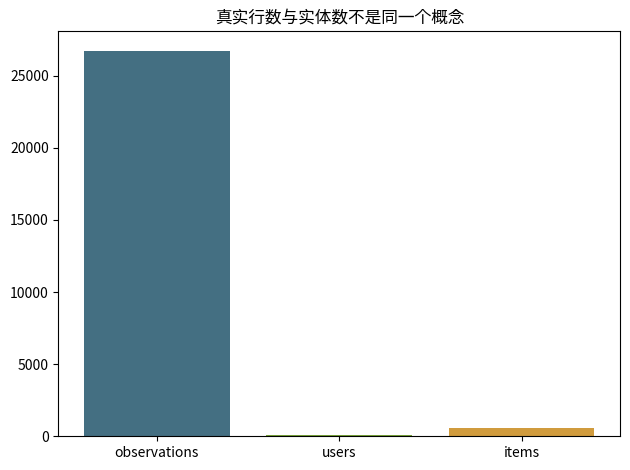

In [2]:
# Demo 1：这些是真实 MovieLens 行，不是人工交互。
columns = ["userId", "movieId", "rating", "timestamp"]
display(real_ratings[columns].head())
entity_counts = np.array([len(real_ratings), real_ratings.userId.nunique(), real_ratings.movieId.nunique()])
print({"observations": int(entity_counts[0]), "user_entities": int(entity_counts[1]),
       "item_entities": int(entity_counts[2])})
plt.bar(["observations", "users", "items"], entity_counts, color=["#446f82", "#79a53b", "#d09b3d"])
plt.title("真实行数与实体数不是同一个概念"); plt.tight_layout(); plt.show()
assert len(real_ratings) > real_ratings.userId.nunique()

<a id="implicit-feedback"></a>
## 2. 显式、隐式反馈与“未知不等于负例”

评分是显式反馈；点击、观看、收藏是隐式反馈。隐式反馈只说明行为发生了，不保证用户真正喜欢。更关键的是：目录中没出现的物品可能没被曝光，所以“没有点击”可能是未知，而不是真负例。只有日志明确记录“曝光后未点击”，才有资格直接成为未点击标签；训练时人工抽出的负样本必须标明采样规则。

监督学习用已有标签预测答案；自监督学习从数据自身构造答案，例如遮住序列中的电影再预测；多任务学习同时预测点击、长播、收藏。三者改变的是学习题目，不会改变原始事实。

### 数字代入 3：分母决定点击率含义

用户得到 100 次曝光，点击 8 次，曝光点击率为 $8/100=8\%$。若日志只保存 8 次点击，不能写成 $8/8=100\%$；后者的分母已经丢失。

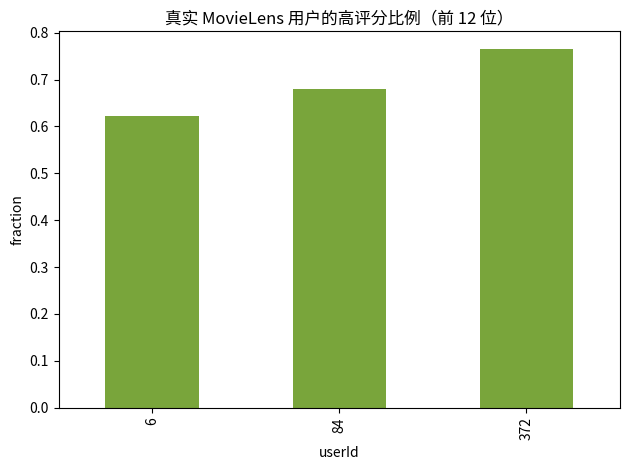

   userId  movieId  rating  timestamp  high_rating_label
0       6      590     5.0  845553109                  1
1       6      592     3.0  845553109                  0
2       6      150     4.0  845553110                  1
3       6      296     2.0  845553110                  0
4       6      380     4.0  845553110                  1


In [3]:
# Demo 2：用真实评分派生一个“高评分”教学标签，同时保留来源行。
sample = real_ratings[["userId", "movieId", "rating", "timestamp"]].head(200).copy()
sample["high_rating_label"] = (sample.rating >= 4.0).astype(int)
rates = sample.groupby("userId").high_rating_label.mean().head(12)
rates.plot(kind="bar", color="#79a53b", title="真实 MovieLens 用户的高评分比例（前 12 位）")
plt.ylabel("fraction"); plt.tight_layout(); plt.show()
print(sample.head())
assert set(sample.high_rating_label.unique()).issubset({0, 1})

<a id="split-leakage"></a>
## 3. 切分、泄漏、基线与泛化

训练集用于拟合参数，验证集用于选模型，测试集只在最终报告时使用。推荐系统通常按用户内时间切分：用过去预测未来。泄漏包括把未来行为放进历史、用全数据计算归一化统计、反复查看测试结果调参。

基线是最简单的合理方案，例如热门推荐或逻辑回归；新模型必须在同一切分、候选集和指标上比较。泛化指模型能否在未见过的未来样本上继续工作。离线指标只能回答既定日志和协议中的问题，还要警惕曝光偏差、热门偏差、假负例和概率校准。

### 数字代入 4：时间边界

某用户事件时间为 $[2,5,9,12]$。leave-last-out 得训练 $[2,5,9]$、测试 $[12]$。若把时间 12 的电影加入训练历史，再预测时间 12，答案已经泄漏。

## 常见误区

- “没点就是不喜欢”：未曝光与曝光未点必须分开。
- “随机切分更平均”：它可能把未来信息放到过去。
- “ID 是普通数值”：ID 只用于定位类别，不能直接解释大小。
- “AUC 高就一定上线好”：概率校准、候选分布、时延与业务目标仍需检查。

## 算法回链

- [GBDT+LR：曝光标签与校准](/notebooks/4_5_gbdt_lr)
- [DSSM：负采样与训练/服务分布](/notebooks/5_2_dssm)
- [SASRec：严格的时间序列切分](/notebooks/5_4_sasrec)
- [DIN：候选与行为历史的语义](/notebooks/6_3_din)
- [MMoE：点击和长播多任务](/notebooks/7_2_mmoe)

## Checks

1. 为什么“目录中没出现”不能直接写成负反馈？
2. 预测点击时，哪些列在预测发生前可知？
3. 为什么测试集不能参与选择学习率？

In [4]:
ordered = real_ratings.sort_values(["userId", "timestamp", "movieId"])
last = ordered.groupby("userId").tail(1)
train = ordered.drop(last.index)
assert set(train.index).isdisjoint(last.index)
assert (train.groupby("userId").timestamp.max() <= last.set_index("userId").timestamp).all()
print("PASS：真实行可追溯；标签、实体计数和按用户时间切分检查通过。")

PASS：真实行可追溯；标签、实体计数和按用户时间切分检查通过。


## Next Steps

下一课把 one-hot、embedding、行为矩阵与序列统一成向量、矩阵和张量；回到算法页时，先写清楚一行数据的语义，再看模型公式。